# Uncertainty Quantification: Ensembles and Latent-Gaussian Forecasts

This notebook assumes the encode → Koopman step → decode workflow from
[`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb); here we wrap that loop
with ensemble and latent-Gaussian forecast UQ.

It demonstrates predictive intervals for `GraphKoopmanModel` via the
power-user module `koopman_graph.uq`.

### Caveats: what this is (and is not)

- **Deep ensembles** (Lakshminarayanan et al., NeurIPS 2017): train several
  independently seeded models and form an empirical mean plus quantile
  bounds with `predict_interval`. Epistemic diversity comes from different
  initializations / fits.
- **Latent-Gaussian / Kalman-refined UQ:** the library's per-node row-state
  advance is \(z \leftarrow z K^\top\) (see `01` / architecture). The UQ peer
  lifts that map to a flattened process model \(A = I \otimes K\) so the
  Gaussian predict step is the usual
  \(P \leftarrow A P A^\top + Q\), then forms observation-space intervals by
  Monte Carlo decoding. Optional mid-horizon observations apply a Kalman
  update (related to the Kalman half of K²VAE-style pipelines; **not** a full
  VAE + KalmanNet reimplementation).
- **Not Deep Probabilistic Koopman (DPK):** DPK typically predicts
  time-varying distribution parameters (often without the same step-by-step
  latent rollout contract used here).

Both wrappers **compose** ordinary `GraphKoopmanModel` instances; they do not
subclass the primary model or fork latent rollout. Import from
`koopman_graph.uq` (not the root façade).


## Method: ensemble and latent-Gaussian UQ

Fit an independently seeded ensemble, report predictive intervals and empirical
coverage, then compare to latent-Gaussian forecast UQ on one fitted member.

Coverage here is illustrative: a short noisy holdout, five ensemble members
(coarse quantiles), and a deliberately wide latent prior can disagree sharply
with the nominal level — calibrate on your domain before treating bands as
decision thresholds.


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import torch
import matplotlib.pyplot as plt

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.datasets import SyntheticDynamicGraphBenchmark
from koopman_graph.uq import (
    EnsembleGraphKoopmanModel,
    LatentGaussianKoopmanUQ,
    empirical_coverage,
)

# Data
NUM_NODES = 8
NUM_TIMESTEPS = 40
IN_CHANNELS = 1
TOPOLOGY = "ring"
NOISE_STD = 0.04
DATA_SEED = 42
TRAIN_STEPS = 28
FORECAST_HORIZON = 6

# Model
HIDDEN_CHANNELS = 8
LATENT_DIM = 4
TIME_STEP = 1.0

# Ensemble training
N_MEMBERS = 5
INIT_SEEDS = (0, 1, 2, 3, 4)
FIT_SEEDS = (100, 101, 102, 103, 104)
EPOCHS = 40
LR = 1e-2

# Evaluation / latent-Gaussian UQ
LEVEL = 0.9
PLOT_NODE = 0
PROCESS_NOISE = 1e-3
INITIAL_COVARIANCE = 1.0
N_MC_SAMPLES = 64
MC_GENERATOR_SEED = 7


## Helper functions

Notebook-local helpers used below.


In [2]:
def make_member() -> GraphKoopmanModel:
    encoder = GNNEncoder(
        in_channels=IN_CHANNELS,
        hidden_channels=HIDDEN_CHANNELS,
        latent_dim=LATENT_DIM,
    )
    decoder = GNNDecoder(
        latent_dim=LATENT_DIM,
        hidden_channels=HIDDEN_CHANNELS,
        out_channels=IN_CHANNELS,
    )
    return GraphKoopmanModel(
        encoder=encoder,
        decoder=decoder,
        latent_dim=LATENT_DIM,
        time_step=TIME_STEP,
    )


## Generate noisy synthetic diffusion data


In [3]:
sequence = SyntheticDynamicGraphBenchmark.generate(
    num_nodes=NUM_NODES,
    num_timesteps=NUM_TIMESTEPS,
    in_channels=IN_CHANNELS,
    topology=TOPOLOGY,
    noise_std=NOISE_STD,
    seed=DATA_SEED,
)
train = sequence[:TRAIN_STEPS]
initial = train[-1]
targets = list(sequence[TRAIN_STEPS : TRAIN_STEPS + FORECAST_HORIZON])
print(f"train steps={len(train)}, forecast horizon={len(targets)}")


train steps=28, forecast horizon=6


## Train: independently seeded ensemble


In [4]:
ensemble = EnsembleGraphKoopmanModel.from_factory(
    make_member,
    n_members=N_MEMBERS,
    seeds=INIT_SEEDS,
)
histories = ensemble.fit(
    train,
    epochs=EPOCHS,
    lr=LR,
    seeds=FIT_SEEDS,
)
print("final train losses:", [round(h.loss[-1], 4) for h in histories])


final train losses: [0.0057, 0.007, 0.0053, 0.0055, 0.0057]


## Evaluate: predictive intervals and empirical coverage

`empirical_coverage` is entrywise over all forecast steps, nodes, and features.
The plot below shows one node for readability; we also print that node's
coverage so it is not confused with the global figure.


nominal level=0.90, global coverage=0.188, node 0 coverage=0.333, mean |error|=0.128
Undercoverage here is often forecast bias plus coarse 5-member quantiles, not a claim that 90% intervals are well calibrated on this toy holdout.


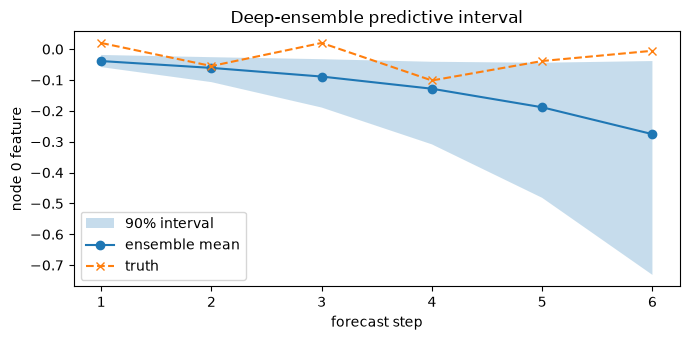

In [5]:
interval = ensemble.predict_interval(
    initial, steps=len(targets), level=LEVEL
)
coverage = empirical_coverage(targets, interval)

node_hits = 0
for t in range(len(targets)):
    x_t = targets[t].x[PLOT_NODE]
    inside = (
        (x_t >= interval.lower[t].x[PLOT_NODE])
        & (x_t <= interval.upper[t].x[PLOT_NODE])
    )
    node_hits += int(bool(inside.all().item()))
node_coverage = node_hits / len(targets)
mean_abs_err = sum(
    (interval.mean[t].x - targets[t].x).abs().mean().item()
    for t in range(len(targets))
) / len(targets)

print(
    f"nominal level={LEVEL:.2f}, global coverage={coverage:.3f}, "
    f"node {PLOT_NODE} coverage={node_coverage:.3f}, "
    f"mean |error|={mean_abs_err:.3f}"
)
print(
    "Undercoverage here is often forecast bias plus coarse 5-member quantiles, "
    "not a claim that 90% intervals are well calibrated on this toy holdout."
)

steps = range(1, len(targets) + 1)
truth = [snap.x[PLOT_NODE, 0].item() for snap in targets]
mean = [snap.x[PLOT_NODE, 0].item() for snap in interval.mean]
lower = [snap.x[PLOT_NODE, 0].item() for snap in interval.lower]
upper = [snap.x[PLOT_NODE, 0].item() for snap in interval.upper]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.fill_between(
    steps, lower, upper, alpha=0.25, label=f"{int(LEVEL * 100)}% interval"
)
ax.plot(steps, mean, marker="o", label="ensemble mean")
ax.plot(steps, truth, marker="x", linestyle="--", label="truth")
ax.set_xlabel("forecast step")
ax.set_ylabel(f"node {PLOT_NODE} feature")
ax.set_title("Deep-ensemble predictive interval")
ax.legend()
fig.tight_layout()
plt.show()


## Results: latent-Gaussian forecast UQ comparison

Reuse one fitted ensemble member (no second training loop). Latent-Gaussian
bands use a wide isotropic prior (`INITIAL_COVARIANCE`) and Monte Carlo
decoding, so they can over-cover even when the ensemble under-covers.
Pass a seeded `torch.Generator` so the Monte Carlo quantiles are Restart &
Run All stable. Panels use independent y-scales so the narrow ensemble band
stays readable next to the wide latent-Gaussian band.


ensemble coverage=0.188, latent-Gaussian coverage=1.000 (wide P0=1; not interchangeable with deep ensembles)


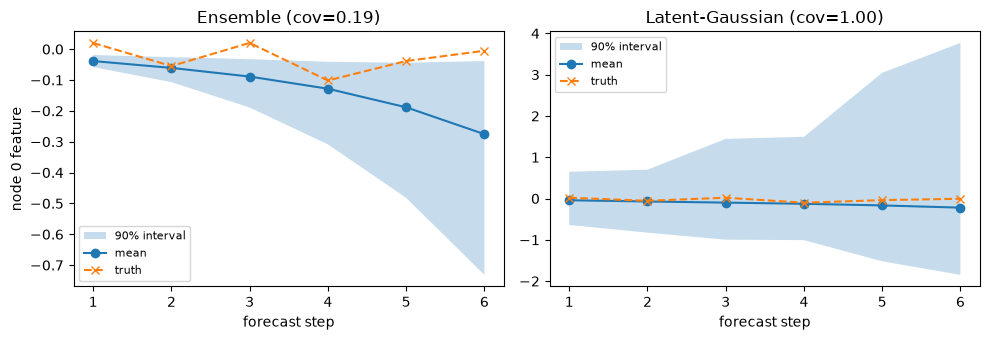

In [6]:
# Reuse a fitted ensemble member (no second training loop).
gauss = LatentGaussianKoopmanUQ(
    ensemble.members[0],
    process_noise=PROCESS_NOISE,
    initial_covariance=INITIAL_COVARIANCE,
    n_samples=N_MC_SAMPLES,
)
mc_generator = torch.Generator().manual_seed(MC_GENERATOR_SEED)
gauss_interval = gauss.predict_interval(
    initial,
    steps=len(targets),
    level=LEVEL,
    generator=mc_generator,
)
gauss_coverage = empirical_coverage(targets, gauss_interval)
print(
    f"ensemble coverage={coverage:.3f}, "
    f"latent-Gaussian coverage={gauss_coverage:.3f} "
    f"(wide P0={INITIAL_COVARIANCE:g}; not interchangeable with deep ensembles)"
)

g_mean = [snap.x[PLOT_NODE, 0].item() for snap in gauss_interval.mean]
g_lower = [snap.x[PLOT_NODE, 0].item() for snap in gauss_interval.lower]
g_upper = [snap.x[PLOT_NODE, 0].item() for snap in gauss_interval.upper]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=False)
for ax, title, m, lo, hi, cov in [
    (axes[0], "Ensemble", mean, lower, upper, coverage),
    (axes[1], "Latent-Gaussian", g_mean, g_lower, g_upper, gauss_coverage),
]:
    ax.fill_between(
        steps, lo, hi, alpha=0.25, label=f"{int(LEVEL * 100)}% interval"
    )
    ax.plot(steps, m, marker="o", label="mean")
    ax.plot(steps, truth, marker="x", linestyle="--", label="truth")
    ax.set_title(f"{title} (cov={cov:.2f})")
    ax.set_xlabel("forecast step")
    ax.legend(fontsize=8)
axes[0].set_ylabel(f"node {PLOT_NODE} feature")
fig.tight_layout()
plt.show()

# Soft teaching check for this seeded toy holdout:
# Teaching point: ensemble under-covers relative to latent-Gaussian on this toy.
assert 0.0 <= coverage <= 1.0
assert 0.0 <= gauss_coverage <= 1.0
assert coverage < gauss_coverage
assert len(gauss_interval.mean) == len(targets)


## Takeaways

- Use `EnsembleGraphKoopmanModel` for epistemic uncertainty via independently
  seeded fits; use `LatentGaussianKoopmanUQ` for linear-Gaussian latent
  propagation (optional Kalman refine) on a **single** fitted model.
- Both expose optional `predict_interval` (`IntervalForecastModel`); neither
  is required on `ForecastModel`, and neither is on the root façade.
- Name claims carefully: ensembles ≠ DPK; latent-Gaussian UQ ≠ full K²VAE and
  ≠ DPK.
- Coverage on a short noisy teaching example is illustrative (bias, coarse
  ensemble quantiles, and prior scale can dominate); calibrate on your domain
  before treating intervals as decision thresholds.

## Next steps

- See [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb) for the deterministic base workflow.
- See [`08_loss_stability.ipynb`](08_loss_stability.ipynb) for loss terms that affect forecast consistency.
- See [`25_kalman_koopman_state_estimation.ipynb`](25_kalman_koopman_state_estimation.ipynb) for latent Kalman / RTS imputation (`KoopmanObserver`); latent-Gaussian UQ can also take mid-horizon `observations=` for open-loop Kalman refine.
- Explore the [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html).
